In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from scikeras.wrappers import KerasClassifier
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, average_precision_score


import keras_tuner
# !pip install keras_tuner
from keras_tuner import RandomSearch

from tensorflow.keras.regularizers import l2  as L2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.metrics import Precision, Recall, AUC


# Install: !pip install shap
import shap

import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    auc
)
from sklearn.utils import shuffle

import os

In [2]:
df_train = pd.read_csv('../data/data/FEwithMerchants/FE_train_downsampled_1to10_with_merchants.csv')
df_val = pd.read_csv('../data/data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/data/FEwithMerchants/FE_test_with_merchants.csv')

In [3]:
selected_features = [
    # transaction-level features
    'step', 'type', 'day', 'amountLog', 'amount_to_oldbalanceOrg','dayOfWeek','hourOfDay',
    # 'amount',         
                
    # account-level features
    'meanSent', 'numUniqueDest', 'numUniqueOrig',
    'transaction_sequence',
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h', 'oldbalanceOrg', 'oldbalanceDest',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction',  'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "receiver_indeg_amt",
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff", 'sender_btwn',
    'receiver_btwn', 'btwn_diff'
]

In [4]:
len(selected_features)

52

In [5]:
missing_features = [col for col in df_train.columns if col not in selected_features]
print("Missing features:", missing_features)

Missing features: ['amount', 'nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud', 'avgAmountPerType', 'p95AmountPerType', 'amountBucket', 'fraudProbabilityByAmountBin', 'dayOfWeekName', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig']


## Data Processing

Encoding categorical columns

In [6]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
columns_to_encode = ['type', 'transaction_sequence', 'typeHighValueFlag']


encoder.fit(df_train[columns_to_encode])


encoded_train = encoder.transform(df_train[columns_to_encode])
encoded_test = encoder.transform(df_test[columns_to_encode])
encoded_val = encoder.transform(df_val[columns_to_encode])


encoded_columns = encoder.get_feature_names_out(columns_to_encode).tolist()


encoded_df_train = pd.DataFrame(encoded_train, columns=encoded_columns, index=df_train.index)
encoded_df_test = pd.DataFrame(encoded_test, columns=encoded_columns, index=df_test.index)
encoded_df_val = pd.DataFrame(encoded_val, columns=encoded_columns, index=df_val.index)

df_train = pd.concat([df_train, encoded_df_train], axis=1)
df_test = pd.concat([df_test, encoded_df_test], axis=1)
df_val = pd.concat([df_val, encoded_df_val], axis=1)

In [7]:
# remove original categorical names from selected_features and append encoded names
selected_features = [c for c in selected_features if c not in columns_to_encode] + encoded_columns

# drop original categorical columns from dataframes to avoid string columns later
df_train = df_train.drop(columns=columns_to_encode, errors='ignore')
df_test  = df_test.drop(columns=columns_to_encode, errors='ignore')
df_val   = df_val.drop(columns=columns_to_encode, errors='ignore')

In [8]:
# Prepare data
X_train_final = df_train[selected_features].copy()
y_train_final = df_train['isFraud'].copy()
X_test_final = df_test[selected_features].copy()
y_test_final = df_test['isFraud'].copy()
X_val_final = df_val[selected_features].copy()
y_val_final = df_val['isFraud'].copy()

In [9]:
print(f"Training set shape:   {df_train.shape}")
print(f"Test set shape:       {df_test.shape}")
print(f"Validation set shape: {df_val.shape}")

# Check if all have same columns
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)
val_cols = set(df_val.columns)

if train_cols == test_cols == val_cols:
    print("\n✓ All datasets have matching columns!")
else:
    print("\n✗ WARNING: Column mismatch detected!")
    print(f"Columns in train but not test: {train_cols - test_cols}")
    print(f"Columns in test but not train: {test_cols - train_cols}")

print(f"\nFinal feature count: {len(df_train.columns)}")
print(f"Feature names: {df_train.columns.tolist()}")

Training set shape:   (63239, 75)
Test set shape:       (954393, 75)
Validation set shape: (954393, 75)

✓ All datasets have matching columns!

Final feature count: 75
Feature names: ['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest', 'oldbalanceDest', 'isFlaggedFraud', 'isFraud', 'amount_to_oldbalanceOrg', 'day', 'avgAmountToDest', 'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 'avgAmountPerType', 'p95AmountPerType', 'amountLog', 'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'numUniqueDest', 'numUniqueOrig', 'transactionRecency', 'sequence_frequency', 'is_cashin_transfer_cashout', 'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 'is_early_transaction', 'sequence_count', 'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pct

Configure a Balanced Train dataset 

In [10]:
fraud_df = df_train[df_train['isFraud'] == 1]
legit_df  = df_train[df_train['isFraud'] == 0]
n_min = len(fraud_df)
train_balanced = pd.concat([fraud_df, legit_df.sample(n=n_min, random_state=42)])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = train_balanced[selected_features].copy()
y_train_balanced = train_balanced['isFraud'].copy()

print("Balanced training shape:", X_train_balanced.shape, "Fraud rate:", y_train_balanced.mean())

Balanced training shape: (11498, 62) Fraud rate: 0.5


Scaling Numerical columns [Imbalanced]

In [11]:
print("\nScaling features...(Imbalanced)")

numeric_cols = X_train_final.select_dtypes(include=['number']).columns
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
])

imbalanced_X_train_scaled = preprocessor.fit_transform(X_train_final)
imbalanced_X_test_scaled = preprocessor.transform(X_test_final)
imbalanced_X_val_scaled = preprocessor.transform(X_val_final)

# Handle NaN/Inf
imbalanced_X_train_scaled = np.nan_to_num(imbalanced_X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
imbalanced_X_test_scaled = np.nan_to_num(imbalanced_X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
imbalanced_X_val_scaled = np.nan_to_num(imbalanced_X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

imbalanced_y_train = y_train_final.values.astype(int)
imbalanced_y_test = y_test_final.values.astype(int)
imbalanced_y_val = y_val_final.values.astype(int)

print(f"Train: {imbalanced_X_train_scaled.shape}, Fraud rate: {imbalanced_y_train.mean():.4f}")
print(f"Val: {imbalanced_X_val_scaled.shape}, Fraud rate: {imbalanced_y_val.mean():.4f}")
print(f"Test: {imbalanced_X_test_scaled.shape}, Fraud rate: {imbalanced_y_test.mean():.4f}")


Scaling features...(Imbalanced)


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train: (63239, 62), Fraud rate: 0.0909
Val: (954393, 62), Fraud rate: 0.0013
Test: (954393, 62), Fraud rate: 0.0013


Scaling Numerical columns [Balanced]

In [12]:
print("\nScaling features...(Balanced)")

numeric_cols = X_train_balanced.select_dtypes(include=['number']).columns
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
])

balanced_X_train_scaled = preprocessor.fit_transform(X_train_final)
balanced_X_test_scaled = preprocessor.transform(X_test_final)
balanced_X_val_scaled = preprocessor.transform(X_val_final)

# Handle NaN/Inf
balanced_X_train_scaled = np.nan_to_num(balanced_X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
balanced_X_test_scaled = np.nan_to_num(balanced_X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
balanced_X_val_scaled = np.nan_to_num(balanced_X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

balanced_y_train = y_train_final.values.astype(int)
balanced_y_test = y_test_final.values.astype(int)
balanced_y_val = y_val_final.values.astype(int)

print(f"Train: {balanced_X_train_scaled.shape}, Fraud rate: {balanced_y_train.mean():.4f}")
print(f"Val: {balanced_X_val_scaled.shape}, Fraud rate: {balanced_y_val.mean():.4f}")
print(f"Test: {balanced_X_test_scaled.shape}, Fraud rate: {balanced_y_test.mean():.4f}")


Scaling features...(Balanced)


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train: (63239, 62), Fraud rate: 0.0909
Val: (954393, 62), Fraud rate: 0.0013
Test: (954393, 62), Fraud rate: 0.0013


In [13]:
feature_names = X_train_final.columns.tolist()
feature_names

['step',
 'day',
 'amountLog',
 'amount_to_oldbalanceOrg',
 'dayOfWeek',
 'hourOfDay',
 'meanSent',
 'numUniqueDest',
 'numUniqueOrig',
 'totalSent',
 'stdSent',
 'numSent',
 'totalReceived',
 'meanReceived',
 'stdReceived',
 'numReceived',
 'maxAmountReceived',
 'stdAmountReceived',
 'avgAmountToDest',
 'std_to_mean_ratio',
 'pctForwarded24h',
 'oldbalanceOrg',
 'oldbalanceDest',
 'transactionRecency',
 'is_early_transaction',
 'sequence_frequency',
 'sequence_count',
 'is_transfer_cashout',
 'is_cashin_transfer',
 'is_cashout_transfer',
 'is_cashin_transfer_cashout',
 'is_transfer_transfer',
 'is_first_transfer',
 'is_cashin_cashout',
 'receiver_indeg_amt',
 'sender_outdeg_amt',
 'sender_indeg_amt',
 'receiver_outdeg_amt',
 'sender_outdeg_cnt',
 'sender_indeg_cnt',
 'receiver_outdeg_cnt',
 'receiver_indeg_cnt',
 'outdeg_amt_diff',
 'indeg_amt_diff',
 'outdeg_cnt_diff',
 'indeg_cnt_diff',
 'sender_btwn',
 'receiver_btwn',
 'btwn_diff',
 'type_CASH_IN',
 'type_CASH_OUT',
 'type_DEBIT',

In [14]:
len(feature_names)

62

Class weights for IMBALANCED dataset training

In [15]:
classes = np.unique(imbalanced_y_train)
class_weight_values = compute_class_weight('balanced', classes=classes, y=imbalanced_y_train)
class_weights = dict(zip(classes.astype(int), class_weight_values))

## Building & Training Neural Network

Part 1: Training on Balanced dataset

In [16]:
def build_model(input_dim, **kwargs):
    model = Sequential([
        Input(shape=(input_dim,)),
        
        Dense(128, kernel_regularizer=L2(0.01), kernel_initializer=HeNormal()),
        LeakyReLU(negative_slope=0.1),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, kernel_regularizer=L2(0.01), kernel_initializer=HeNormal()),
        LeakyReLU(negative_slope=0.1),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(32, kernel_regularizer=L2(0.01), kernel_initializer=HeNormal()),
        LeakyReLU(negative_slope=0.1),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])

    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR')
    ]
)

    
    return model

# Wrap model in scikit-learn compatible interface
model_Balanced = KerasClassifier(model=build_model(input_dim=balanced_X_train_scaled.shape[1]), epochs=15, verbose=0)

In [17]:
# Callbacks [BALANCED]
early_stop_balanced = EarlyStopping(
    monitor='val_pr_auc',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr_balanced = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


print("\nTraining model on BALANCED train dataset...")
history_stage1 = model_Balanced.fit(
    balanced_X_train_scaled, balanced_y_train,
    validation_data=(balanced_X_val_scaled, balanced_y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop_balanced, reduce_lr_balanced],
    verbose=1
)


Training model on BALANCED train dataset...
Epoch 1/60
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 2.3392 - pr_auc: 0.5564 - precision: 0.5818 - recall: 0.4763 - val_loss: 1.0442 - val_pr_auc: 0.1619 - val_precision: 0.1444 - val_recall: 0.2670
Epoch 2/60
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.4883 - pr_auc: 0.7631 - precision: 0.7837 - recall: 0.6105 - val_loss: 0.4891 - val_pr_auc: 0.1936 - val_precision: 0.1229 - val_recall: 0.2443
Epoch 3/60
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.2114 - pr_auc: 0.8054 - precision: 0.8137 - recall: 0.6693 - val_loss: 0.2601 - val_pr_auc: 0.1321 - val_precision: 0.0922 - val_recall: 0.3880
Epoch 4/60
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1586 - pr_auc: 0.8279 - precision: 0.8272 - recall: 0.6893 - val_loss: 0.1029 - val_pr_auc: 0.1963 - val_precision: 0.0651 - val_recall: 0.6071
Epoch 5/60
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1406 - pr_auc: 0.8488 - precision: 0.8424 - recall: 0.7168 - va

Performance Metrics for BALANCED

In [ ]:
y_pred_proba = model_Balanced.predict(balanced_X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(classification_report(balanced_y_test, y_pred))
print(f"\nPR-AUC: {average_precision_score(balanced_y_test, y_pred_proba):.4f}")


RESULTS
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    953161
           1       0.07      0.70      0.13      1232

    accuracy                           0.99    954393
   macro avg       0.54      0.85      0.56    954393
weighted avg       1.00      0.99      0.99    954393


PR-AUC: 0.0524


Part 2: Training on IMBALANCED dataset

In [19]:
trained_keras_model = model_Balanced.model_


def build_model_with_pretrained_weights(model_stage1):

    model_stage2 = clone_model(model_stage1)
    model_stage2.set_weights(model_stage1.get_weights())  # load pretrained weights
    

    for layer in model_stage2.layers[:4]:  # First 2 dense layers + activations
        layer.trainable = False


    model_stage2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR')
        ]
    )
    return model_stage2

model_imbalanced = KerasClassifier(model=build_model_with_pretrained_weights(trained_keras_model), verbose=0)

In [20]:
trained_keras_model = model_Balanced.model_

# Clone the architecture
model_imbalanced = clone_model(trained_keras_model)

# Build/initialize the model weights
model_imbalanced.build(input_shape=trained_keras_model.input_shape)

# Copy weight values
model_imbalanced.set_weights(trained_keras_model.get_weights())



for layer in model_imbalanced.layers[:4]:  # First 2 dense layers + activations
    layer.trainable = False

model_imbalanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR')
    ]
)

In [21]:
# Callbacks for IMBALANCED dataset
early_stop_stage2 = EarlyStopping(
    monitor='val_pr_auc',
    patience=20,  # More patience for fine-tuning
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr_stage2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

print("\nTraining model on IMBALANCED train dataset...")
history_stage2 = model_imbalanced.fit(
    imbalanced_X_train_scaled, imbalanced_y_train,
    validation_data=(imbalanced_X_val_scaled, imbalanced_y_val),
    epochs=30,  # Fewer epochs for fine-tuning
    batch_size=256,
    class_weight=class_weights,  # Use class weights for imbalanced data
    callbacks=[early_stop_stage2, reduce_lr_stage2],
    verbose=1
)


Training model on IMBALANCED train dataset...
Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.1802 - pr_auc: 0.8933 - precision: 0.6294 - recall: 0.9148 - val_loss: 0.1023 - val_pr_auc: 0.4132 - val_precision: 0.0394 - val_recall: 0.8433 - learning_rate: 3.0000e-04
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1693 - pr_auc: 0.9018 - precision: 0.6244 - recall: 0.9243 - val_loss: 0.1381 - val_pr_auc: 0.3938 - val_precision: 0.0321 - val_recall: 0.8856 - learning_rate: 3.0000e-04
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.1674 - pr_auc: 0.8993 - precision: 0.6207 - recall: 0.9257 - val_loss: 0.1688 - val_pr_auc: 0.3802 - val_precision: 0.0285 - val_recall: 0.8985 - learning_rate: 3.0000e-04
Epoch 4/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.1607 - pr_auc: 0.9029 - precision: 0.6156 - recall: 0.9296 - val_loss: 0.1225 - val_pr_auc: 0.4243 - val_precision: 0.0362 - val_recall: 0.8872 - learning_rate: 3.0000e-04
Epoch 5/30


Performance Metrics for IMBALANCED

In [ ]:
y_pred_proba = model_imbalanced.predict(imbalanced_X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)



print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(classification_report(imbalanced_y_test, y_pred))
print(f"\nPR-AUC: {average_precision_score(imbalanced_y_test, y_pred_proba):.4f}")


RESULTS
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    953161
           1       0.03      0.87      0.06      1232

    accuracy                           0.96    954393
   macro avg       0.52      0.92      0.52    954393
weighted avg       1.00      0.96      0.98    954393


PR-AUC: 0.4509


## Hyperparameter Tuning
Using Keras Tuner RandomSearch

In [ ]:
def build_model(hp):
    # Define hyperparameters to search over
    dropout_rate1 = hp.Float('dropout_rate1', min_value=0.3, max_value=0.5, step=0.1)
    l2_reg = hp.Float('l2_reg', min_value=0.001, max_value=0.01, step=0.002)
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.0005, step=0.0001)
    
    # Define L2 regularizer
    l2 = L2(l2_reg)

    # Build model architecture
    tuned_model = Sequential([
        Input(shape=(imbalanced_X_train_scaled.shape[1],)),
        Dense(128, kernel_regularizer=l2),
        LeakyReLU(negative_slope=0.1),
        BatchNormalization(),
        Dropout(dropout_rate1),

        Dense(64, kernel_regularizer=l2),
        LeakyReLU(negative_slope=0.1),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, kernel_regularizer=l2),
        LeakyReLU(negative_slope=0.1),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])


    tuned_model = clone_model(model_imbalanced)
    tuned_model.set_weights(model_imbalanced.get_weights())
    
    

    for layer in tuned_model.layers[:4]:  # First 2 dense layers + activations
        layer.trainable = False


    # Compile the model
    tuned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR')
        ]
    )
    
    return tuned_model

In [ ]:
tuner = RandomSearch(
    build_model,
    objective=keras_tuner.Objective('pr_auc', direction='max'),
    max_trials=10, 
    executions_per_trial=1
)


tuner.search(
    imbalanced_X_train_scaled,
    imbalanced_y_train,
    epochs=10,
    batch_size=128,
    validation_data=(imbalanced_X_val_scaled, imbalanced_y_val),
    class_weight=class_weights,
    verbose=1
)


best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f"Dropout rate (1st layer): {best_hp.get('dropout_rate1')}")
print(f"L2 regularization: {best_hp.get('l2_reg')}")
print(f"Learning rate: {best_hp.get('learning_rate')}")

Reloading Tuner from .\untitled_project\tuner0.json
Best hyperparameters found:
Dropout rate (1st layer): 0.3
L2 regularization: 0.001
Learning rate: 0.0001


Fitting on the Best Model

In [ ]:
Xtrain_full = np.concatenate([imbalanced_X_train_scaled, imbalanced_X_val_scaled], axis=0)
ytrain_full = np.concatenate([imbalanced_y_train, imbalanced_y_val], axis=0)

Xtrain_full, ytrain_full = shuffle(Xtrain_full, ytrain_full, random_state=42)

In [26]:
best_model = tuner.hypermodel.build(best_hp)
history = best_model.fit(
    Xtrain_full, ytrain_full,
    epochs=80,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='pr_auc', patience=15, restore_best_weights=True, verbose=1, mode = 'max'),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='pr_auc', factor=0.5, patience=5, verbose=1,mode = 'max')
    ],
    verbose=2
)

Epoch 1/80
3976/3976 - 16s - 4ms/step - loss: 0.0458 - pr_auc: 0.6580 - precision: 0.3954 - recall: 0.7694 - learning_rate: 1.0000e-04
Epoch 2/80
3976/3976 - 12s - 3ms/step - loss: 0.0417 - pr_auc: 0.6821 - precision: 0.4216 - recall: 0.7742 - learning_rate: 1.0000e-04
Epoch 3/80
3976/3976 - 12s - 3ms/step - loss: 0.0414 - pr_auc: 0.6845 - precision: 0.4300 - recall: 0.7711 - learning_rate: 1.0000e-04
Epoch 4/80
3976/3976 - 13s - 3ms/step - loss: 0.0408 - pr_auc: 0.6833 - precision: 0.4215 - recall: 0.7738 - learning_rate: 1.0000e-04
Epoch 5/80
3976/3976 - 13s - 3ms/step - loss: 0.0403 - pr_auc: 0.6823 - precision: 0.4302 - recall: 0.7777 - learning_rate: 1.0000e-04
Epoch 6/80
3976/3976 - 13s - 3ms/step - loss: 0.0402 - pr_auc: 0.6877 - precision: 0.4276 - recall: 0.7760 - learning_rate: 1.0000e-04
Epoch 7/80
3976/3976 - 12s - 3ms/step - loss: 0.0402 - pr_auc: 0.6845 - precision: 0.4226 - recall: 0.7755 - learning_rate: 1.0000e-04
Epoch 8/80
3976/3976 - 12s - 3ms/step - loss: 0.0403 - 

## Feature Importance

In [27]:
# ============================================================================
# SHAP (SHapley Additive exPlanations) - MOST COMPREHENSIVE
# ============================================================================

print("\n" + "="*60)
print("CALCULATING SHAP VALUES")
print("="*60)

# Use a sample for efficiency (SHAP can be slow on large datasets)
sample_size = min(100, len(imbalanced_X_val_scaled))
X_sample = np.array(imbalanced_X_val_scaled[:sample_size])
y_sample = np.array(imbalanced_y_val[:sample_size])

# Create SHAP explainer
explainer = shap.GradientExplainer(
    best_model,
    np.array(shap.sample(imbalanced_X_train_scaled, 50))
)

# Calculate SHAP values (this may take a few minutes)
print("Computing SHAP values (this may take a while)...")
shap_values = explainer.shap_values(X_sample)


CALCULATING SHAP VALUES
Computing SHAP values (this may take a while)...


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 62))']
  warnings.warn(msg)
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 62))']
  warnings.warn(msg)


In [28]:
print(f"X_sample shape: {X_sample.shape}")
print(f"shap_values type: {type(shap_values)}")

# Handle different output formats
if isinstance(shap_values, list):
    print(f"shap_values is a list with {len(shap_values)} elements")
    for i, sv in enumerate(shap_values):
        print(f"  Element {i} shape: {sv.shape}")
    
    # For binary classification, usually want the first element (class 1)
    shap_values_to_use = shap_values[0]
else:
    print(f"shap_values shape: {shap_values.shape}")
    shap_values_to_use = shap_values

print(f"\nUsing shap_values with shape: {shap_values_to_use.shape}")
print(f"X_sample shape: {X_sample.shape}")

# Verify shapes match
if shap_values_to_use.shape != X_sample.shape:
    print(f"\n⚠️ WARNING: Shape mismatch!")
    print(f"shap_values shape: {shap_values_to_use.shape}")
    print(f"X_sample shape: {X_sample.shape}")
    
    # Try to fix
    if shap_values_to_use.shape[0] != X_sample.shape[0]:
        print("Sample count mismatch - cannot fix automatically")
    elif shap_values_to_use.shape[1] != X_sample.shape[1]:
        print(f"Feature count mismatch: {shap_values_to_use.shape[1]} vs {X_sample.shape[1]}")
else:
    print("✓ Shapes match!")

X_sample shape: (100, 62)
shap_values type: <class 'numpy.ndarray'>
shap_values shape: (100, 62, 1)

Using shap_values with shape: (100, 62, 1)
X_sample shape: (100, 62)

⚠️ WARNING: Shape mismatch!
shap_values shape: (100, 62, 1)
X_sample shape: (100, 62)


In [29]:
shap_values = shap_values[:, :, 0]
shap_values_to_use = shap_values

In [30]:
print("SHAP shape:", np.array(shap_values_to_use).shape)
print("Number of features:", len(selected_features))

SHAP shape: (100, 62)
Number of features: 62


C:\Users\lylyl\AppData\Local\Temp\ipykernel_6072\1277882373.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, show=False)


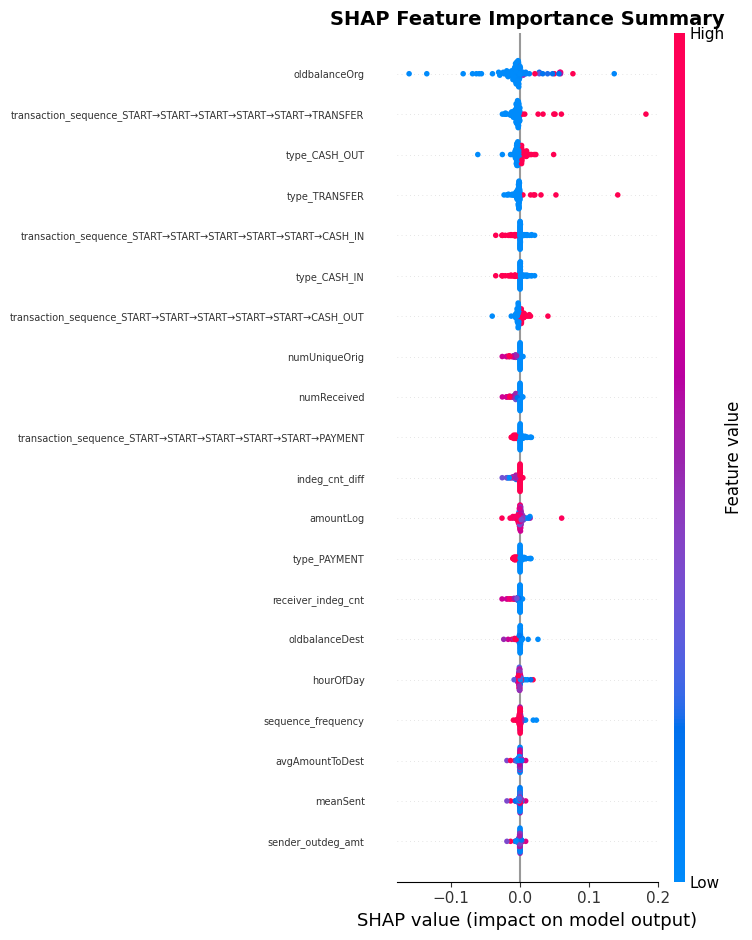

C:\Users\lylyl\AppData\Local\Temp\ipykernel_6072\1277882373.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features,


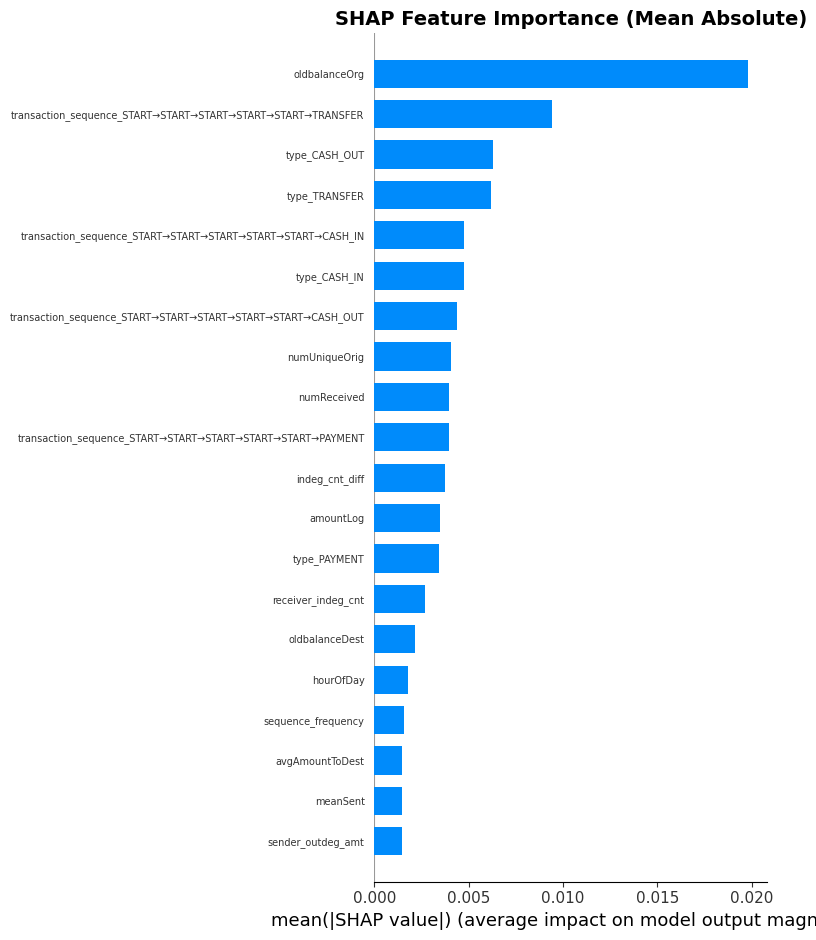


Top 20 Features by SHAP Importance:
                                                    feature  shap_importance
                                              oldbalanceOrg         0.019815
transaction_sequence_START→START→START→START→START→TRANSFER         0.009438
                                              type_CASH_OUT         0.006284
                                              type_TRANSFER         0.006168
 transaction_sequence_START→START→START→START→START→CASH_IN         0.004748
                                               type_CASH_IN         0.004743
transaction_sequence_START→START→START→START→START→CASH_OUT         0.004376
                                              numUniqueOrig         0.004068
                                                numReceived         0.003971
 transaction_sequence_START→START→START→START→START→PAYMENT         0.003947
                                             indeg_cnt_diff         0.003754
                                       

In [31]:
# ============================================================================
# VISUALIZE SHAP VALUES
# ============================================================================

# 1. Summary plot (shows feature importance and impact direction)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, show=False)
plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# 2. Bar plot (average absolute SHAP values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, 
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean Absolute)', fontsize=14, fontweight='bold')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# 3. Feature importance DataFrame
shap_importance = pd.DataFrame({
    'feature': selected_features,
    'shap_importance': np.abs(shap_values_to_use).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\nTop 20 Features by SHAP Importance:")
print(shap_importance.head(20).to_string(index=False))

In [32]:
all_features = pd.DataFrame({'feature': X_train_final.columns})

# Merge with all features, fill missing with 0
feature_importance_df = all_features.merge(shap_importance, on='feature', how='left').fillna(0)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('shap_importance', ascending=False)

# Calculate cumulative importance
feature_importance_df['cumulative_importance'] = (
    feature_importance_df['shap_importance'].cumsum() / feature_importance_df['shap_importance'].sum()
)

print(feature_importance_df.head(20))

top_features = feature_importance_df[
    feature_importance_df['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"Selected {len(top_features)} features explaining 95% of model importance")
print(top_features)

                                              feature  shap_importance  \
21                                      oldbalanceOrg         0.019815   
59  transaction_sequence_START→START→START→START→S...         0.009438   
50                                      type_CASH_OUT         0.006284   
53                                      type_TRANSFER         0.006168   
55  transaction_sequence_START→START→START→START→S...         0.004748   
49                                       type_CASH_IN         0.004743   
56  transaction_sequence_START→START→START→START→S...         0.004376   
8                                       numUniqueOrig         0.004068   
15                                        numReceived         0.003971   
58  transaction_sequence_START→START→START→START→S...         0.003947   
45                                     indeg_cnt_diff         0.003754   
2                                           amountLog         0.003457   
52                                    

## Model Evaluation

In [33]:
# Set style
sns.set_style("whitegrid")

# Get predictions (probabilities)
y_pred_proba = best_model.predict(imbalanced_X_test_scaled, verbose=0).flatten()

# Calculate Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(imbalanced_y_test, y_pred_proba)

# Calculate PR-AUC (Average Precision)
pr_auc = average_precision_score(imbalanced_y_test, y_pred_proba)

# Calculate F1-Score at default threshold (0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)
f1_default = f1_score(imbalanced_y_test, y_pred_default)
precision_default = precision_score(imbalanced_y_test, y_pred_default, zero_division=0)
recall_default = recall_score(imbalanced_y_test, y_pred_default, zero_division=0)

# Find optimal threshold (maximize F1-Score)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-7)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]



# Print results
print(f"\n{'='*60}")
print("METRICS SUMMARY")
print(f"{'='*60}")
print(f"\nPR-AUC (Average Precision): {pr_auc:.4f}")

print(f"\n{'='*60}")
print("F1-SCORE AT DEFAULT THRESHOLD (0.5)")
print(f"{'='*60}")
print(f"F1-Score:  {f1_default:.4f}")
print(f"Precision: {precision_default:.4f}")
print(f"Recall:    {recall_default:.4f}")

print(f"\n{'='*60}")
print("OPTIMAL F1-SCORE")
print(f"{'='*60}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"F1-Score:  {optimal_f1:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall:    {optimal_recall:.4f}")


METRICS SUMMARY

PR-AUC (Average Precision): 0.5401

F1-SCORE AT DEFAULT THRESHOLD (0.5)
F1-Score:  0.3562
Precision: 0.2479
Recall:    0.6323

OPTIMAL F1-SCORE
Optimal Threshold: 0.8404
F1-Score:  0.5622
Precision: 0.7050
Recall:    0.4675


C:\Users\lylyl\AppData\Local\Temp\ipykernel_6072\3927544202.py:26: RuntimeWarning: divide by zero encountered in divide
  y = f1_val * x / (2 * x - f1_val)


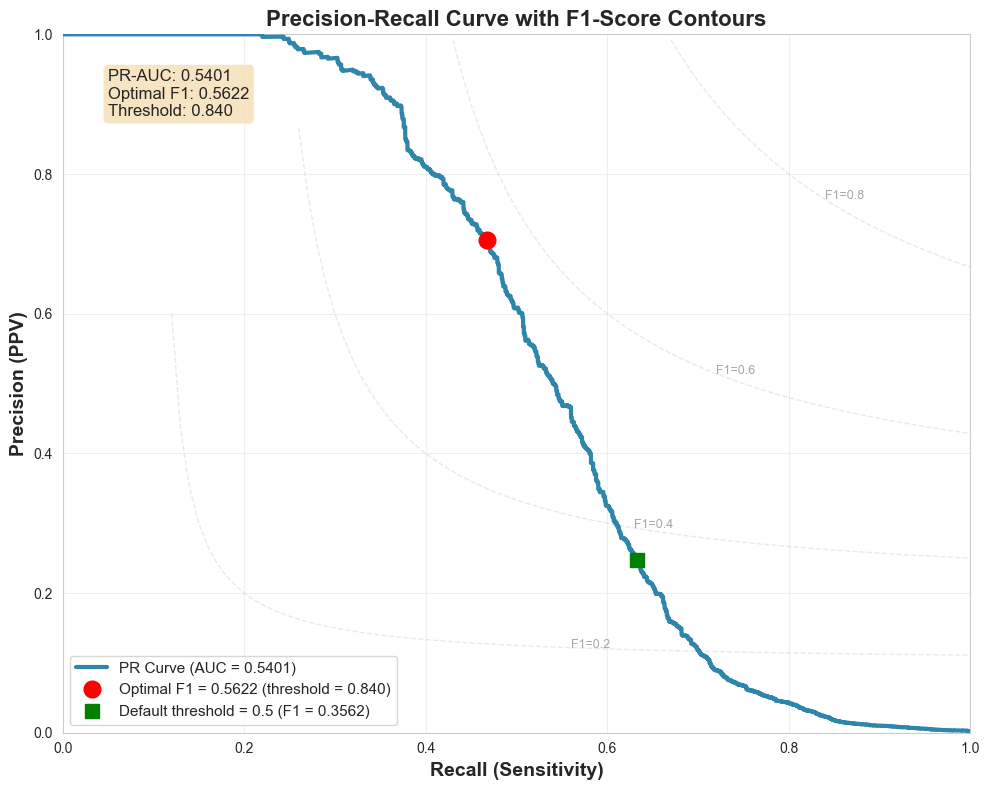

In [34]:
# ============================================================================
# 2. PRECISION-RECALL CURVE WITH F1 CONTOURS
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Plot PR curve
ax.plot(recall, precision, linewidth=3, label=f'PR Curve (AUC = {pr_auc:.4f})', 
        color='#2E86AB', zorder=3)


# Mark optimal F1 point
ax.plot(optimal_recall, optimal_precision, 'ro', markersize=12, 
        label=f'Optimal F1 = {optimal_f1:.4f} (threshold = {optimal_threshold:.3f})',
        zorder=4)

# Mark default threshold point
ax.plot(recall_default, precision_default, 'gs', markersize=10,
        label=f'Default threshold = 0.5 (F1 = {f1_default:.4f})',
        zorder=4)

# Add F1 contour lines
f1_values = np.array([0.2, 0.4, 0.6, 0.8])
for f1_val in f1_values:
    x = np.linspace(0.01, 1, 100)
    y = f1_val * x / (2 * x - f1_val)
    y[y < 0] = np.nan
    y[y > 1] = np.nan
    ax.plot(x, y, '--', color='lightgray', alpha=0.5, linewidth=1, zorder=0)
    # Add F1 label
    idx = np.where(~np.isnan(y))[0]
    if len(idx) > 0:
        mid_idx = len(idx) // 2
        ax.text(x[idx[mid_idx]], y[idx[mid_idx]], f'F1={f1_val:.1f}', 
               fontsize=9, color='gray', alpha=0.7)

ax.set_xlabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=14, fontweight='bold')
ax.set_title('Precision-Recall Curve with F1-Score Contours', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add text box with statistics
textstr = f'PR-AUC: {pr_auc:.4f}\nOptimal F1: {optimal_f1:.4f}\nThreshold: {optimal_threshold:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
# plt.savefig('pr_curve_with_f1.png', dpi=300, bbox_inches='tight')
plt.show()

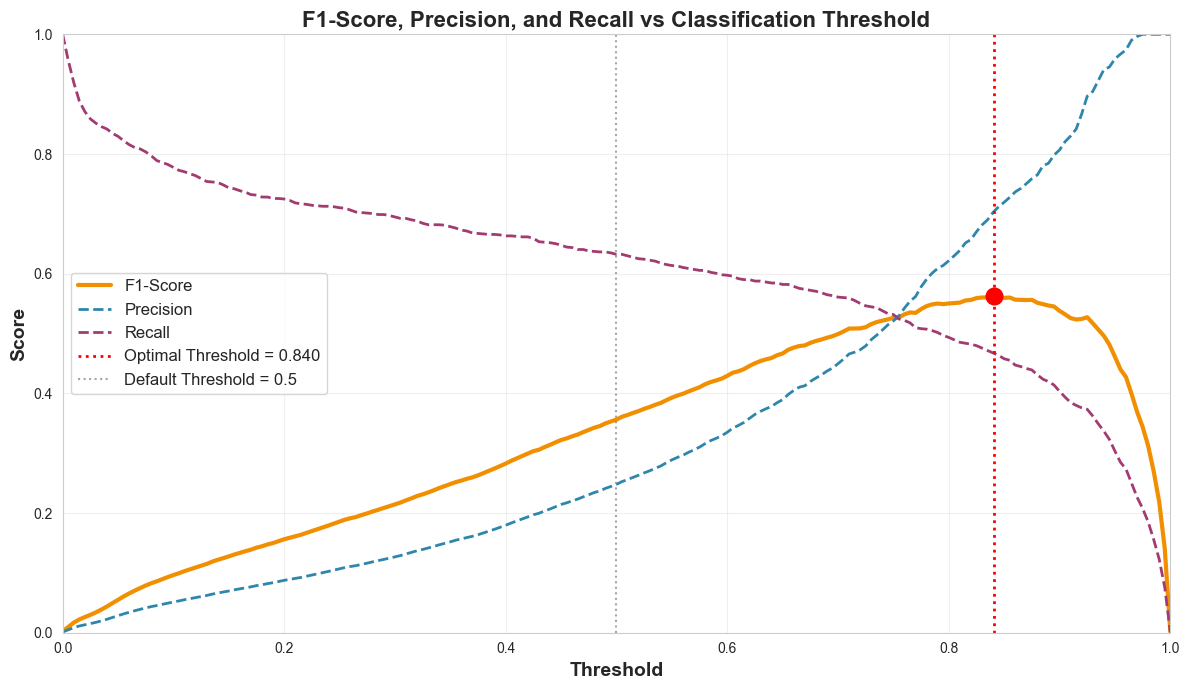

In [35]:
# ============================================================================
# 3. F1-SCORE VS THRESHOLD
# ============================================================================

# Calculate metrics across all thresholds
thresholds_to_test = np.linspace(0, 1, 201)
f1_scores_all = []
precision_scores = []
recall_scores = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    f1_scores_all.append(f1_score(imbalanced_y_test, y_pred_thresh, zero_division=0))
    precision_scores.append(precision_score(imbalanced_y_test, y_pred_thresh, zero_division=0))
    recall_scores.append(recall_score(imbalanced_y_test, y_pred_thresh, zero_division=0))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(thresholds_to_test, f1_scores_all, linewidth=3, 
        label='F1-Score', color='#F18F01')
ax.plot(thresholds_to_test, precision_scores, linewidth=2, 
        label='Precision', color='#2E86AB', linestyle='--')
ax.plot(thresholds_to_test, recall_scores, linewidth=2, 
        label='Recall', color='#A23B72', linestyle='--')

# Mark optimal F1
ax.axvline(x=optimal_threshold, color='red', linestyle=':', linewidth=2, 
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.plot(optimal_threshold, optimal_f1, 'ro', markersize=12)

# Mark default threshold
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, 
           label='Default Threshold = 0.5', alpha=0.7)

ax.set_xlabel('Threshold', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('F1-Score, Precision, and Recall vs Classification Threshold', 
             fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
# plt.savefig('f1_vs_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# ============================================================================
# 4. DETAILED THRESHOLD ANALYSIS TABLE
# ============================================================================

print(f"\n{'='*60}")
print("DETAILED THRESHOLD ANALYSIS")
print(f"{'='*60}")

# Analyze specific thresholds
analysis_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
analysis_results = []

for thresh in analysis_thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    tp = np.sum((imbalanced_y_test == 1) & (y_pred_thresh == 1))
    tn = np.sum((imbalanced_y_test == 0) & (y_pred_thresh == 0))
    fp = np.sum((imbalanced_y_test == 0) & (y_pred_thresh == 1))
    fn = np.sum((imbalanced_y_test == 1) & (y_pred_thresh == 0))
    
    precision = precision_score(imbalanced_y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(imbalanced_y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(imbalanced_y_test, y_pred_thresh, zero_division=0)
    
    analysis_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Frauds Detected': tp,
        'False Alarms': fp
    })

analysis_df = pd.DataFrame(analysis_results)
print("\n" + analysis_df.to_string(index=False))

# Highlight optimal threshold
optimal_row = analysis_df.iloc[(analysis_df['Threshold'] - optimal_threshold).abs().argsort()[0]]
print(f"\n{'='*60}")
print(f"RECOMMENDED THRESHOLD: {optimal_threshold:.3f}")
print(f"{'='*60}")
print(f"This threshold maximizes F1-Score = {optimal_f1:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")


DETAILED THRESHOLD ANALYSIS

 Threshold  Precision   Recall  F1-Score  TP     TN    FP  FN  Frauds Detected  False Alarms
       0.1   0.051378 0.777597  0.096388 958 935473 17688 274              958         17688
       0.2   0.087532 0.724838  0.156201 893 943852  9309 339              893          9309
       0.3   0.126740 0.694805  0.214375 856 947263  5898 376              856          5898
       0.4   0.179600 0.663149  0.282650 817 949429  3732 415              817          3732
       0.5   0.247931 0.632305  0.356196 779 950798  2363 453              779          2363
       0.6   0.335002 0.597403  0.429280 736 951700  1461 496              736          1461
       0.7   0.449577 0.560877  0.499097 691 952315   846 541              691           846
       0.8   0.621677 0.493506  0.550226 608 952791   370 624              608           370
       0.9   0.806818 0.403409  0.537879 497 953042   119 735              497           119

RECOMMENDED THRESHOLD: 0.840
This thres

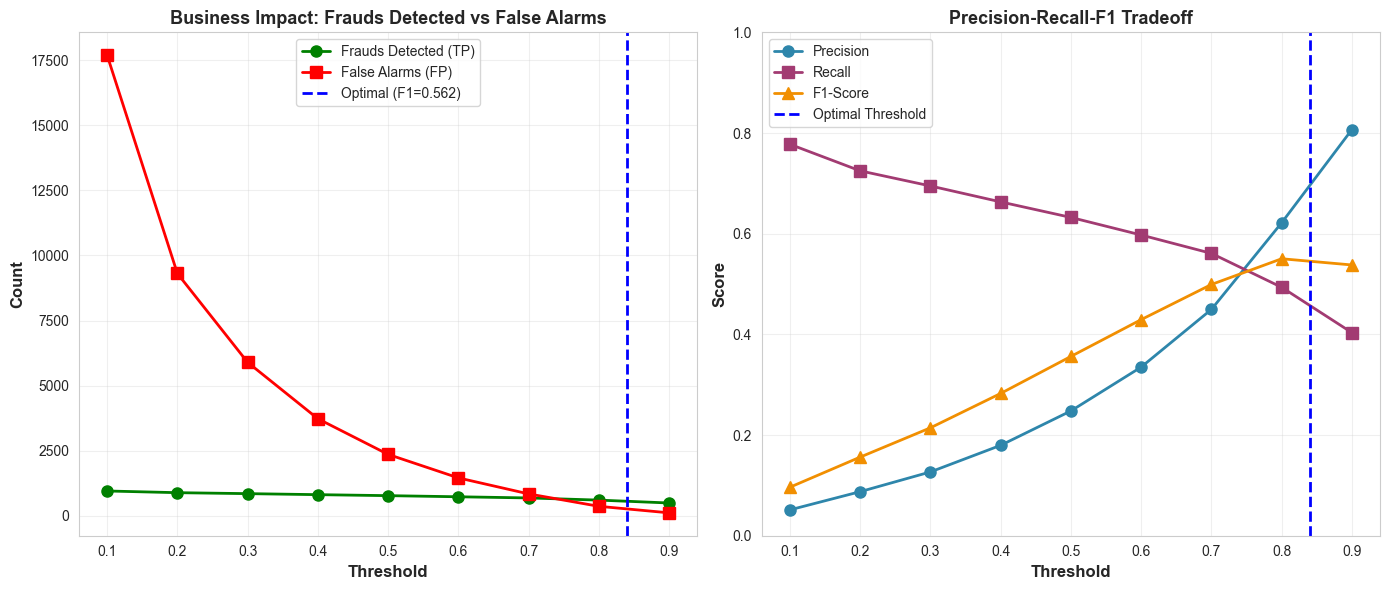

In [37]:
# ============================================================================
# 5. BUSINESS IMPACT VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Frauds detected vs False alarms
axes[0].plot(analysis_df['Threshold'], analysis_df['Frauds Detected'], 
             'o-', linewidth=2, markersize=8, color='green', label='Frauds Detected (TP)')
axes[0].plot(analysis_df['Threshold'], analysis_df['False Alarms'], 
             's-', linewidth=2, markersize=8, color='red', label='False Alarms (FP)')
axes[0].axvline(x=optimal_threshold, color='blue', linestyle='--', linewidth=2, 
                label=f'Optimal (F1={optimal_f1:.3f})')
axes[0].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Business Impact: Frauds Detected vs False Alarms', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Precision-Recall tradeoff
axes[1].plot(analysis_df['Threshold'], analysis_df['Precision'], 
             'o-', linewidth=2, markersize=8, color='#2E86AB', label='Precision')
axes[1].plot(analysis_df['Threshold'], analysis_df['Recall'], 
             's-', linewidth=2, markersize=8, color='#A23B72', label='Recall')
axes[1].plot(analysis_df['Threshold'], analysis_df['F1-Score'], 
             '^-', linewidth=2, markersize=8, color='#F18F01', label='F1-Score')
axes[1].axvline(x=optimal_threshold, color='blue', linestyle='--', linewidth=2, 
                label=f'Optimal Threshold')
axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall-F1 Tradeoff', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
# plt.savefig('business_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# ============================================================================
# SAVE RESULTS TO CSV
# ============================================================================

# # Save threshold analysis
# analysis_df.to_csv('threshold_analysis.csv', index=False)
# print(f"\n✓ Threshold analysis saved to 'threshold_analysis.csv'")

# # Save summary metrics
# summary_metrics = {
#     'Metric': ['PR-AUC', 'F1 (default)', 'F1 (optimal)', 
#                'Optimal Threshold', 'Precision (optimal)', 'Recall (optimal)'],
#     'Value': [pr_auc, f1_default, optimal_f1, 
#               optimal_threshold, optimal_precision, optimal_recall]
# }
# summary_df = pd.DataFrame(summary_metrics)
# summary_df.to_csv('pr_auc_f1_summary.csv', index=False)
# print(f"✓ Summary metrics saved to 'pr_auc_f1_summary.csv'")

In [ ]:
## Save Model
os.makedirs('../models/NN/', exist_ok=True)
best_model.save('../models/NN/NN_1to10_all.keras')

In [40]:
# from keras.models import load_model
# model = load_model('../models/NN/NN_1to5_all.keras')